
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [1]:
from Controller import*
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); milptab = mycontroller.GenerateMILPTab()
tab_set = widgets.Tab([mytab,milptab])
tab_set.set_title(0,'Main');tab_set.set_title(1,'MILP'); tab_set

Start day:  2026-08-28  weekday:  4  day:  Friday , TimeLimit:  None
Controller: Generating dashboard
Visual Manager: Generating dashboard


Item batches: 101
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  CentralBuffer_Location
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_60
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_61
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_62
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_63
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  BW_(BKW_01)_Location
Machine Setup 109 BW_(BKW_01)_Location 602
Machine Loading 674 BW_(BKW_01)_Location 719
Machine Processing 732 BW_(BKW_01)_Location 768
Machine Unloading 748 BW_(BKW_01)_Location 906
Machine Setup 110 BW_(BKW_01)_Location 908
Machine Loading 779 BW_(BKW_01)_Location 953
Machine Processing 796 BW_(BKW_01)_Location 1192
Machine Unloading 842 BW_(BKW_01)_Location 1968
Machine Setup 111 BW_(BKW_01)_Location 1970
Machine Loading 870 BW_(BKW_01)_Location 2073
Machine Processing 920

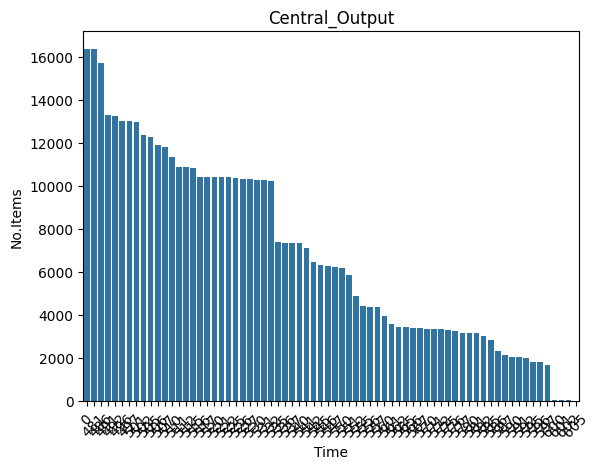

,BufferName,Time,No.Items
0,Central_Output,0,16356
1,Central_Output,481,16339
2,Central_Output,486,15701
3,Central_Output,491,13280
4,Central_Output,492,13256
...,...,...,...
65,Central_Output,597,1674
66,Central_Output,600,69
67,Central_Output,601,64
68,Central_Output,602,60


______________________________


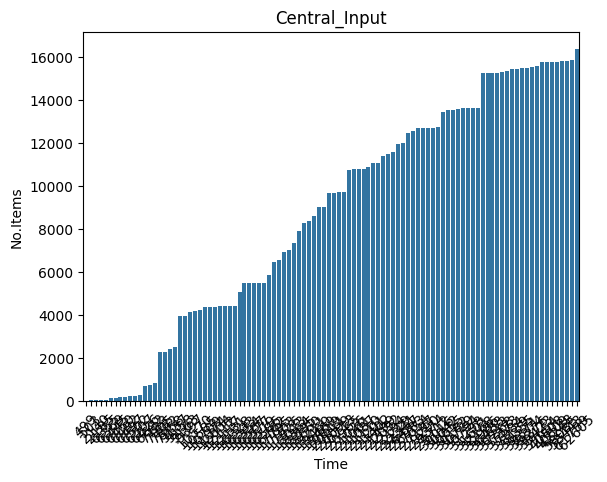

,BufferName,Time,No.Items
0,Central_Input,499,24
1,Central_Input,503,44
2,Central_Input,2140,61
3,Central_Input,2185,65
4,Central_Input,6355,69
...,...,...,...
95,Central_Input,42248,15772
96,Central_Input,58085,15828
97,Central_Input,58443,15836
98,Central_Input,61789,15856


______________________________


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

exec_df = pd.read_csv("EventExecutionData.csv")

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    #if start != end:
    #    display(sub_df)
    
    #    print("______________________________")
    

#process_df = exec_df[exec_df["EventName"] == "Machine Processing"]

for myloc in exec_df["Location"].unique():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("Location: ",myloc)
    sub_df = exec_df[exec_df["Location"] == myloc]
    sub_df  = sub_df[(sub_df["EventName"] == "Machine Setup") | (sub_df["EventName"] =="Machine Loading") | (sub_df["EventName"] == "Machine Processing") | (sub_df["EventName"] == "Machine Unloading")]
    if diagnose and len(sub_df)  > 0:
        for i,r in sub_df.iterrows():
            print(r["EventName"],r["EventID"],r["Location"],r["SimTime"])
        
        #display(sub_df)

    


print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv("BufferData.csv")

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [ ]:
import pandas as pd

location_df = pd.read_csv("LocationData.csv")

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    

In [ ]:
# Importing the matplotlib.pyplot
import matplotlib.pyplot as plt

# Declaring a figure "gnt"
fig, gnt = plt.subplots()

# Setting Y-axis limits
gnt.set_ylim(0, 50)

# Setting X-axis limits
gnt.set_xlim(0, 160)

# Setting labels for x-axis and y-axis
gnt.set_xlabel('seconds since start')
gnt.set_ylabel('Processor')

# Setting ticks on y-axis
gnt.set_yticks([15, 25, 35])
# Labelling tickes of y-axis
gnt.set_yticklabels(['1', '2', '3'])

# Setting graph attribute
gnt.grid(True)

# Declaring a bar in schedule
gnt.broken_barh([(40, 50)], (30, 9), facecolors =('tab:orange'))

# Declaring multiple bars in at same level and same width
gnt.broken_barh([(110, 10), (150, 10)], (10, 9),
                         facecolors ='tab:blue')

gnt.broken_barh([(10, 50), (100, 20), (130, 10)], (20, 9),
                                  facecolors =('tab:red'))


In [2]:
import pandas as pd
exec_df = pd.read_csv("EventExecutionData.csv")

demands_df = exec_df.groupby(['Items','ID','PN','EventName','EventID','Operation','Resource','Date'])['SimTime'].agg(lambda x:list(x)).reset_index()

for demand in demands_df['ID'].unique():
    demand_df = demands_df[demands_df["ID"] == demand]
    demand_df['Date']  = pd.to_datetime(demand_df['Date'], format="%Y-%m-%d %H:%M:%S")
    display(demand_df)


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
0,10013~10072,__export__.mrp_production_7013_6a3eaa93,[4022-455-09992],Machine Processing,2008,M3-01 - AW - 3axis - Manual (FR3_01),M3-01_(FR3_01),2026-09-09 11:19:00,[17959]
1,10013~10072,__export__.mrp_production_7013_6a3eaa93,[4022-455-09992],Machine Processing,2304,BW - Benchwork (BKW_01),BW_(BKW_01),2026-09-11 00:29:00,[20189]
2,10013~10072,__export__.mrp_production_7013_6a3eaa93,[4022-455-09992],Machine Processing,2415,PACK - Packaging (VERP_P),PACK_(VERP_P),2026-09-11 16:28:00,[21148]
3,10013~10072,__export__.mrp_production_7013_6a3eaa93,[4022-455-09992],Trailer Unloading,2437,-,Operator 3,2026-09-11 17:21:00,[21201]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
4,10073~10112,__export__.mrp_production_7014_5c77ebb4,[4022-455-09997-3],Machine Processing,872,M5-02 - AW - 5axis - Pallet Automation (FR5_02),M5-02_(FR5_02),2026-08-31 13:57:00,[5157]
5,10073~10112,__export__.mrp_production_7014_5c77ebb4,[4022-455-09997-3],Machine Processing,2897,M3-01 - AW - 3axis - Manual (FR3_01),M3-01_(FR3_01),2026-09-18 00:57:00,[30297]
6,10073~10112,__export__.mrp_production_7014_5c77ebb4,[4022-455-09997-3],Machine Processing,2923,PACK - Packaging (VERP_P),PACK_(VERP_P),2026-09-18 09:08:00,[30788]
7,10073~10112,__export__.mrp_production_7014_5c77ebb4,[4022-455-09997-3],Trailer Unloading,2927,-,Operator 1,2026-09-18 09:14:00,[30794]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
8,10113~10138,__export__.mrp_production_7596_c18ab2f0,[4022.695.89661],Machine Processing,1190,M5-01 - AW - 5axis - Conveyor Automation (FR5_01),M5-01_(FR5_01),2026-09-02 13:50:00,[8030]
9,10113~10138,__export__.mrp_production_7596_c18ab2f0,[4022.695.89661],Machine Processing,1613,M5-01 - AW - 5axis - Conveyor Automation (FR5_01),M5-01_(FR5_01),2026-09-04 15:18:00,[10998]
10,10113~10138,__export__.mrp_production_7596_c18ab2f0,[4022.695.89661],Trailer Unloading,1703,-,Operator 3,2026-09-04 21:34:00,[11374]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
11,10139~10170,__export__.mrp_production_6453_22d700ce,[7005-2480-0070],Machine Processing,1076,M3-03 - VF - 3axis - Manual (VF2SS),VF2SS_(M3-03),2026-09-01 11:02:00,[6422]
12,10139~10170,__export__.mrp_production_6453_22d700ce,[7005-2480-0070],Machine Processing,1661,BW - Benchwork (BKW_01),BW_(BKW_01),2026-09-04 08:17:00,[10577]
13,10139~10170,__export__.mrp_production_6453_22d700ce,[7005-2480-0070],Trailer Unloading,1676,-,Operator 1,2026-09-04 08:25:00,[10585]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
14,10171~10485,__export__.mrp_production_7205_3768da3c,[4022-635-87291],Machine Processing,2072,M3-01 - AW - 3axis - Manual (FR3_01),M3-01_(FR3_01),2026-09-09 18:40:00,[18400]
15,10171~10485,__export__.mrp_production_7205_3768da3c,[4022-635-87291],Machine Processing,2332,BW - Benchwork (BKW_01),BW_(BKW_01),2026-09-11 14:15:00,[21015]
16,10171~10485,__export__.mrp_production_7205_3768da3c,[4022-635-87291],Machine Processing,2439,PACK - Packaging (VERP_P),PACK_(VERP_P),2026-09-11 22:37:00,[21517]
17,10171~10485,__export__.mrp_production_7205_3768da3c,[4022-635-87291],Trailer Unloading,2482,-,Manual worker 1,2026-09-14 08:12:00,[24972]


...

,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
319,9018~9021,__export__.mrp_production_7583_751bfa1f,N26241507V01-04 - JH Bottom Cover,Machine Processing,931,"MP3 - Mat. prep - pre-cutted, only picking (UI...",MP3_(UITG_M),2026-08-31 11:33:00,[5013]
320,9018~9021,__export__.mrp_production_7583_751bfa1f,N26241507V01-04 - JH Bottom Cover,Trailer Unloading,978,-,Manual worker 2,2026-08-31 12:25:00,[5065]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
321,9022~9221,__export__.mrp_production_6391_80325cfc,[4022-666-3837-1],Machine Processing,1310,BW - Benchwork (BKW_01),BW_(BKW_01),2026-09-02 16:34:00,[8194]
322,9022~9221,__export__.mrp_production_6391_80325cfc,[4022-666-3837-1],Machine Processing,1547,PACK - Packaging (VERP_P),PACK_(VERP_P),2026-09-03 12:20:00,[9380]
323,9022~9221,__export__.mrp_production_6391_80325cfc,[4022-666-3837-1],Trailer Unloading,1601,-,Manual worker 2,2026-09-03 12:37:00,[9397]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
324,9222~9875,__export__.mrp_production_7591_7e8691ac,[00385-00-320-A],Machine Processing,949,M4-01 - AW - 4axis - Conveyor Automation (FR4_01),M4-01_(FR4_01),2026-09-03 10:17:00,[9257]
325,9222~9875,__export__.mrp_production_7591_7e8691ac,[00385-00-320-A],Machine Processing,1787,BW - Benchwork (BKW_01),BW_(BKW_01),2026-09-07 21:20:00,[15680]
326,9222~9875,__export__.mrp_production_7591_7e8691ac,[00385-00-320-A],Machine Processing,1864,OUT - Outsourced activity,OUT - Outsourced activity_(OUT - Outsourced),2026-09-09 21:58:00,[18598]
327,9222~9875,__export__.mrp_production_7591_7e8691ac,[00385-00-320-A],Machine Processing,2164,PACK - Packaging (VERP_P),PACK_(VERP_P),2026-09-10 19:07:00,[19867]
328,9222~9875,__export__.mrp_production_7591_7e8691ac,[00385-00-320-A],Trailer Unloading,2277,-,Operator 3,2026-09-10 21:31:00,[20011]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
329,9876~9878,__export__.mrp_production_7763_0bcf2bf4,[4022.737.00811/AA],Machine Processing,815,MP1 - Mat. prep - automatic sawing (ZGN_01),MP1 - Material preparation - automatic sawing ...,2026-08-28 17:23:00,[1043]
330,9876~9878,__export__.mrp_production_7763_0bcf2bf4,[4022.737.00811/AA],Machine Processing,2825,M3-01 - AW - 3axis - Manual (FR3_01),M3-01_(FR3_01),2026-09-17 14:52:00,[29692]
331,9876~9878,__export__.mrp_production_7763_0bcf2bf4,[4022.737.00811/AA],Trailer Unloading,2837,-,Operator 2,2026-09-17 15:12:00,[29712]


,Items,ID,PN,EventName,EventID,Operation,Resource,Date,SimTime
332,9879~10012,__export__.mrp_production_7009_954f0f2c,[4022-631-99701],Machine Processing,1492,BW - Benchwork (BKW_01),BW_(BKW_01),2026-09-03 19:11:00,[9791]
333,9879~10012,__export__.mrp_production_7009_954f0f2c,[4022-631-99701],Machine Processing,1653,PACK - Packaging (VERP_P),PACK_(VERP_P),2026-09-04 10:20:00,[10700]
334,9879~10012,__export__.mrp_production_7009_954f0f2c,[4022-631-99701],Trailer Unloading,1685,-,Operator 1,2026-09-04 10:29:00,[10709]
